# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
I replaced the starter corpus with my own small paragraph related to data science, deep learning, and sequence models.  
This keeps the notebook easy to run while still giving the models enough repeated context to learn simple next-word patterns.

In [3]:
corpus = '''
data science helps me understand patterns hidden inside real world data
deep learning models learn from examples and improve with training
sequence models read words step by step and remember useful context
recurrent neural networks are simple models for sequential information
lstm networks remember long term dependencies better than vanilla rnn
gru networks are faster and still capture meaningful context in text
text generation predicts the next word based on previous words
language models learn grammar sentence flow and contextual relationships
as a student i use experiments to compare models and understand results
this notebook compares rnn lstm and gru for simple text generation
'''
print(corpus)


data science helps me understand patterns hidden inside real world data
deep learning models learn from examples and improve with training
sequence models read words step by step and remember useful context
recurrent neural networks are simple models for sequential information
lstm networks remember long term dependencies better than vanilla rnn
gru networks are faster and still capture meaningful context in text
text generation predicts the next word based on previous words
language models learn grammar sentence flow and contextual relationships
as a student i use experiments to compare models and understand results
this notebook compares rnn lstm and gru for simple text generation



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 78
X shape: (94, 11)
y shape: (94,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [5]:
# Increased embedding dimension and hidden units as part of the learning task
embedding_dim = 64
hidden_units = 128
num_epochs = 200

rnn_model = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_len-1),
    SimpleRNN(hidden_units),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=num_epochs, verbose=0)
print("Vanilla RNN training completed")

c:\Users\Aradhya Gupta\Desktop\DataScience001\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_len-1),
    LSTM(hidden_units),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=num_epochs, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [7]:
gru_model = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_len-1),
    GRU(hidden_units),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=num_epochs, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss
I compared the loss curves of all three models after increasing epochs to 200. This helps show how each architecture learns the text patterns over time.

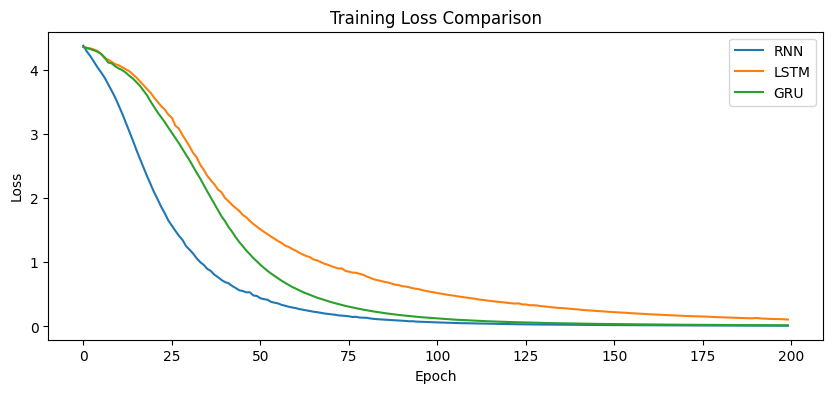

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [9]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        if output_word == "":
            break

        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [10]:
seed_text = "data science"

print("RNN :", generate_text(rnn_model, seed_text, 10))
print("LSTM:", generate_text(lstm_model, seed_text, 10))
print("GRU :", generate_text(gru_model, seed_text, 10))

RNN : data science helps me understand patterns hidden inside real world data science
LSTM: data science helps me understand patterns hidden inside real world data data
GRU : data science helps me understand patterns hidden inside real world data data


# 📚 Student Learning Tasks
### ✅ Beginner Tasks Completed
1. Replaced the starter corpus with my own paragraph
2. Increased embedding dimension from 32 to 64
3. Increased epochs from 100 to 200
4. Changed hidden units from 64 to 128
5. Generated 10 words instead of 5

These changes helped me compare how Vanilla RNN, LSTM, and GRU behave when the same corpus and training setup are used.

# ✅ Conclusion
- **Vanilla RNN** can learn short text patterns, but it struggles when the sentence needs longer memory.
- **LSTM** performs better for long-range grammar and contextual dependencies because its gates control what to remember and what to forget.
- **GRU** gives similar sequence learning performance with fewer gates, so it is usually faster and simpler than LSTM.
- After increasing the embedding dimension, hidden units, epochs, and generated words, this notebook gives a practical comparison of how sequence models learn text structure.
- Overall, this project helped me understand text generation, next-word prediction, and the difference between RNN, LSTM, and GRU in a clear hands-on way.